## Business Problem

#### A global e-commerce company operating across multiple regions manages end-to-end order fulfillment, including shipping and delivery, for products like sporting goods. The company is facing inconsistent delivery performance, where actual shipping times often deviate from scheduled timelines, leading to late deliveries and unpredictable order profitability.



## Diesired Outcome:

#### The goal is to analyze delivery operations, identify bottlenecks, and build a predictive system to reduce delays, optimize shipping decisions, and improve overall profitability and efficiency.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm

import warnings
warnings.filterwarnings('ignore')  # fixed closing parenthesis

# set professional color theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

viridis_colors = cm.viridis(np.linspace(1, 0, 5))

primary_color = viridis_colors[0]
secondary_color = '#800000'
neutral_color = viridis_colors[4]

custom_palette = viridis_colors


In [21]:
# set professional color theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

viridis_colors = cm.viridis(np.linspace(1, 0, 5))

primary_color = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color = viridis_colors[2]
danger_color = '#800000'
neutral_color = viridis_colors[4]

custom_palette = viridis_colors


In [23]:
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding = 'latin-1')

In [24]:
(df['Benefit per order'] == df ['Order Profit Per Order']).value_counts()

True    180519
Name: count, dtype: int64

In [25]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

## Exploratory Data Analysis(EDA)

In [30]:
print('row, cols:', df.shape)

print('\ncolumns:')
print(df.columns.tolist())

print('\nNum duplicates:', df.duplicated().sum())

print('\nMissing values (top 20):')
print(df.isna().sum().sort_values(ascending=False).head(20))

row, cols: (180519, 53)

columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product

In [32]:
# Clean column names (very important)
df.columns = df.columns.str.strip()

# Columns to drop
columns_to_drop = [
    'Product Description',
    'Product Image',
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Order Zipcode',
    'Longitude',
    'Latitude',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Item Total',
    'Category Id',
    'Department Id',
    'Order Id',
    'Order Customer Id',
    'Customer Id',
    'Product Cart Id',
    'Product Category Id',
    'Benefit per order',
    'Product Status',
    'Customer City',
    'Order City',
    'Order Country',
    'Order State',
    'Customer State',
    'Market'
]

# Drop columns safely
df = df.drop(columns=columns_to_drop, errors='ignore')

# Remove canceled orders (based on Delivery Status)
if 'Delivery Status' in df.columns:
    df = df[df['Delivery Status'] != 'Shipping Canceled']

# Convert date columns safely
date_cols = ['order date (DateOrders)', 'Shipping date (DateOrders)']
for c in date_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors='coerce')

# Final check
print('rows, cols:', df.shape)

print('\nMissing values (top 5):')
print(df.isna().sum().sort_values(ascending=False).head(5))

rows, cols: (180519, 21)

Missing values (top 5):
Type                          0
Order Item Profit Ratio       0
shipping date (DateOrders)    0
Product Price                 0
Product Name                  0
dtype: int64


In [33]:
for col in df.columns:
    if df[col].nunique() < 10:
        print(f'\n{col} value counts:')
        print(df[col].value_counts())


Type value counts:
Type
DEBIT       69295
TRANSFER    49883
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real) value counts:
Days for shipping (real)
2    56618
3    28765
6    28723
4    28513
5    28163
0     5080
1     4657
Name: count, dtype: int64

Days for shipment (scheduled) value counts:
Days for shipment (scheduled)
4    107752
2     35216
1     27814
0      9737
Name: count, dtype: int64

Delivery Status value counts:
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

Late_delivery_risk value counts:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Customer Country value counts:
Customer Country
EE. UU.        111146
Puerto Rico     69373
Name: count, dtype: int64

Customer Segment value counts:
Customer Segment
Consumer       93504
Corporate      54789
Home Office    32226
Name: count, dtype: int64

Order Status value c

In [36]:
# Order Processing Time
if 'shipping date (dateorders)' in df.columns and 'order date (dateorders)' in df.columns:
    df['order_processing_time'] = (
        df['shipping date (dateorders)'] - df['order date (dateorders)']
    ).dt.days

# Delay
if 'order_processing_time' in df.columns and 'days for shipment (scheduled)' in df.columns:
    df['delay'] = df['order_processing_time'] - df['days for shipment (scheduled)']

# Delayed flag
if 'delay' in df.columns:
    df['is_delayed'] = df['delay'] > 0

# Date features
if 'order date (dateorders)' in df.columns:
    df['order_month'] = df['order date (dateorders)'].dt.month
    df['order_day'] = df['order date (dateorders)'].dt.day_name()
    df['order_hour'] = df['order date (dateorders)'].dt.hour

# Summary
print(df.describe())

       Days for shipping (real)  Days for shipment (scheduled)  \
count             180519.000000                  180519.000000   
mean                   3.497654                       2.931847   
min                    0.000000                       0.000000   
25%                    2.000000                       2.000000   
50%                    3.000000                       4.000000   
75%                    5.000000                       4.000000   
max                    6.000000                       4.000000   
std                    1.623722                       1.374449   

       Sales per customer  Late_delivery_risk        order date (DateOrders)  \
count       180519.000000       180519.000000                         180519   
mean           183.107609            0.548291  2016-06-12 17:47:04.669868544   
min              7.490000            0.000000            2015-01-01 00:00:00   
25%            104.379997            0.000000            2015-09-21 13:49:00   
50%  

In [38]:
# Convert columns to datetime
df['shipping date (DateOrders)'] = pd.to_datetime(
    df['shipping date (DateOrders)'], errors='coerce'
)

df['order date (DateOrders)'] = pd.to_datetime(
    df['order date (DateOrders)'], errors='coerce'
)

# Now calculate Order Processing Time
df['Order Processing Time'] = (
    df['shipping date (DateOrders)'] - df['order date (DateOrders)']
).dt.days

# Delay calculation
df['Delay'] = df['Order Processing Time'] - df['Days for shipment (scheduled)']

# Delayed flag
df['Is_Delayed'] = df['Delay'] > 0

# Date features
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day'] = df['order date (DateOrders)'].dt.day_name()
df['order_hour'] = df['order date (DateOrders)'].dt.hour

In [40]:
df['Is_Delayed'].value_counts()

Is_Delayed
True     98743
False    81776
Name: count, dtype: int64

In [42]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Card Id', 'Product Name', 'Product Price',
       'shipping date (DateOrders)', 'Shipping Mode', 'Order Processing Time',
       'Delay', 'Is_Delayed', 'order_month', 'order_day', 'order_hour'],
      dtype='object')

In [44]:
df['Order Profit Per Order']

0          91.250000
1        -249.089996
2        -247.779999
3          22.860001
4         134.210007
             ...    
180514     40.000000
180515   -613.770019
180516    141.110001
180517    186.229996
180518    168.949997
Name: Order Profit Per Order, Length: 180519, dtype: float64

In [46]:
df['Profitablity Flag'] = np.where(df['Order Profit Per Order'] > 0, 'Profit', np.where(df['Order Profit Per Order'] < 0, 'Loss', 'Bread-even'))
df['Profitablity Flag'].value_counts()

Profitablity Flag
Profit        145558
Loss           33784
Bread-even      1177
Name: count, dtype: int64

In [48]:
df['Profitablity Flag'].value_counts(normalize=True)

Profitablity Flag
Profit        0.806331
Loss          0.187149
Bread-even    0.006520
Name: proportion, dtype: float64

## Profitablity Analysis
#### 4.1 Profitablity Distribution

#### Order-level profitability was classified into three tiers based on Order Profit Per Order. While 80.7% of orders are profitable, the 18.7% loss-making share

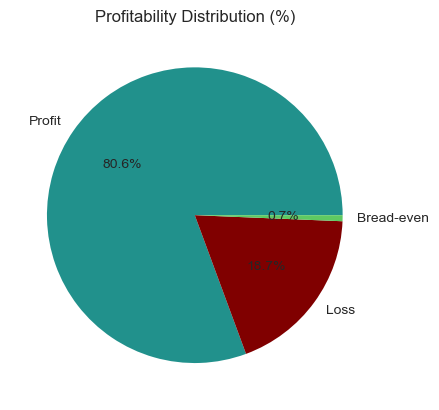

In [52]:
# Visualization of profitability distribution
profit_counts = df['Profitablity Flag'].value_counts(normalize=True) * 100

profit_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=[accent_color, danger_color, secondary_color]
)

plt.ylabel('')  # correct spelling
plt.title('Profitability Distribution (%)')
plt.show()

In [54]:
def format_func(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'


# Filter delayed orders
delayed_df = df[df['Delay'] > 0]

metrics = {}

metrics['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)

metrics['90% Delay (days)'] = delayed_df['Delay'].quantile(0.90)

metrics['On time Delivery %'] = (
    1 - metrics['Late Deliveries'] / metrics['Total Orders']
) * 100

metrics['Late Delivery %'] = (
    metrics['Late Deliveries'] / metrics['Total Orders']
) * 100

# Total Profit
metrics['Total Profit'] = format_func(
    df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum()
)

# ✅ Loss due to delays (FIXED LOGIC)
loss_due_to_delays = df.loc[
    (df['Delay'] > 0) & (df['Order Profit Per Order'] < 0),
    'Order Profit Per Order'
].sum()

metrics['Total Loss due to delays'] = format_func(abs(loss_due_to_delays))

# Print results
print('\n--- Business KPIs ---\n')

for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")


--- Business KPIs ---

Total Orders: 180519
Late Deliveries: 98743
90% Delay (days): 3.00
On time Delivery %: 45.30
Late Delivery %: 54.70
Total Profit: 7.9M $
Total Loss due to delays: 2.1M $


In [56]:
def format_func(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'

delayed_df = df[df['Delay'] > 0]
metrics = {}
metrics['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)
metrics['90% Delay (days)'] = delayed_df['Delay'].quantile(0.90)
metrics['On time Delivery %'] = (1 - metrics['Late Deliveries'] / metrics['Total Orders']) * 100
metrics['Late Delivery %'] = (metrics['Late Deliveries'] / metrics['Total Orders']) * 100
metrics['Total Profit'] = format_func(df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum())
loss_due_to_delays = df.loc[ (df['Delay'] > 0) & (df['Order Profit Per Order'] < 0),'Order Profit Per Order'].sum()
metrics['Total Loss due to delays'] = format_func(abs(loss_due_to_delays))

print('\n--- Business KPIs ---\n')

for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")


--- Business KPIs ---

Total Orders: 180519
Late Deliveries: 98743
90% Delay (days): 3.00
On time Delivery %: 45.30
Late Delivery %: 54.70
Total Profit: 7.9M $
Total Loss due to delays: 2.1M $


### Profitability vs Delevery Time Analysis

In [59]:
profit_metrics = (
    df.groupby('Delay')['Order Profit Per Order']
    .agg(
        mean_profit='mean',
        total_profit='sum',
        order_count='count'
    )
    .reset_index()
)

In [61]:
profit_metrics

,Delay,mean_profit,total_profit,order_count
0,-2,23.423528,5.074942e+05,21666
1,-1,21.516997,4.669188e+05,21700
2,0,22.044854,8.467429e+05,38410
3,1,22.225592,1.244411e+06,55990
4,2,21.246239,6.101495e+05,28718
5,3,19.941130,1.406248e+05,7052
6,4,21.561202,1.505619e+05,6983


In [63]:
delay_distribution = (
    df['Delay']
    .value_counts(normalize = True)
    .sort_index() * 100
).reset_index()

In [65]:
delay_distribution

,Delay,proportion
0,-2,12.002061
1,-1,12.020895
2,0,21.277539
3,1,31.016126
4,2,15.908575
5,3,3.906514
6,4,3.868291


In [67]:
delay_distribution = (
    df['Delay']
    .value_counts(normalize = True)
    .sort_index () * 100
).reset_index()

In [69]:
delay_distribution

,Delay,proportion
0,-2,12.002061
1,-1,12.020895
2,0,21.277539
3,1,31.016126
4,2,15.908575
5,3,3.906514
6,4,3.868291



Profit Metrics by Delay Day:
   Delay  mean_profit  total_profit  order_count
0     -2         23.4      507494.2        21666
1     -1         21.5      466918.8        21700
2      0         22.0      846742.9        38410
3      1         22.2     1244410.9        55990
4      2         21.2      610149.5        28718
5      3         19.9      140624.8         7052
6      4         21.6      150561.9         6983

Delay Distribution (%):
   Delay_Days  Percentage
0          -2   12.002061
1          -1   12.020895
2           0   21.277539
3           1   31.016126
4           2   15.908575
5           3    3.906514
6           4    3.868291


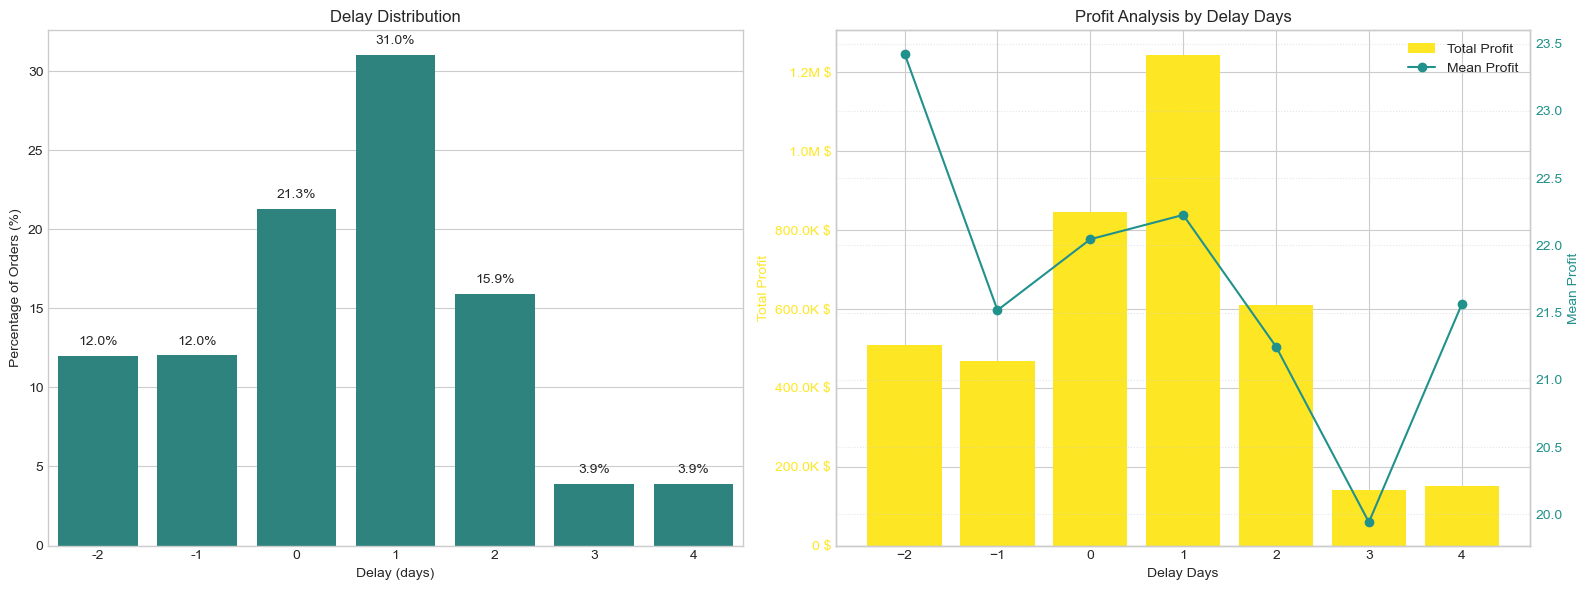

In [71]:
# Rename columns
delay_distribution.columns = ['Delay_Days', 'Percentage']

# Display data
print("\nProfit Metrics by Delay Day:")
print(profit_metrics.round(1))

print("\nDelay Distribution (%):")
print(delay_distribution)

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ------------------ Left Plot ------------------
sns.barplot(
    x='Delay_Days',
    y='Percentage',
    data=delay_distribution,
    color=accent_color,
    ax=ax1
)

ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (days)')
ax1.set_ylabel('Percentage of Orders (%)')

# Add labels on bars
for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom'
    )

# ------------------ Right Plot ------------------
# Bar plot (Total Profit)
ax2.bar(
    profit_metrics['Delay'],
    profit_metrics['total_profit'],
    color=primary_color,
    label='Total Profit'
)

ax2.set_xlabel('Delay Days')
ax2.set_ylabel('Total Profit', color=primary_color)
ax2.tick_params(axis='y', labelcolor=primary_color)

# Line plot (Mean Profit)
ax3 = ax2.twinx()

ax3.plot(
    profit_metrics['Delay'],
    profit_metrics['mean_profit'],
    marker='o',
    color=accent_color,
    label='Mean Profit'
)

ax3.set_ylabel('Mean Profit', color=accent_color)
ax3.tick_params(axis='y', labelcolor=accent_color)

# Format numbers (K, M)
def format_func(x, pos):
    if x >= 1e6:
        return f'{x/1e6:.1f}M $'
    elif x >= 1e3:
        return f'{x/1e3:.1f}K $'
    return f'{x:.0f} $'

ax2.yaxis.set_major_formatter(ticker.FuncFormatter(format_func))

# Title
ax2.set_title('Profit Analysis by Delay Days')

# Legend
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# Grid + layout
ax3.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

# Bottleneck Detection

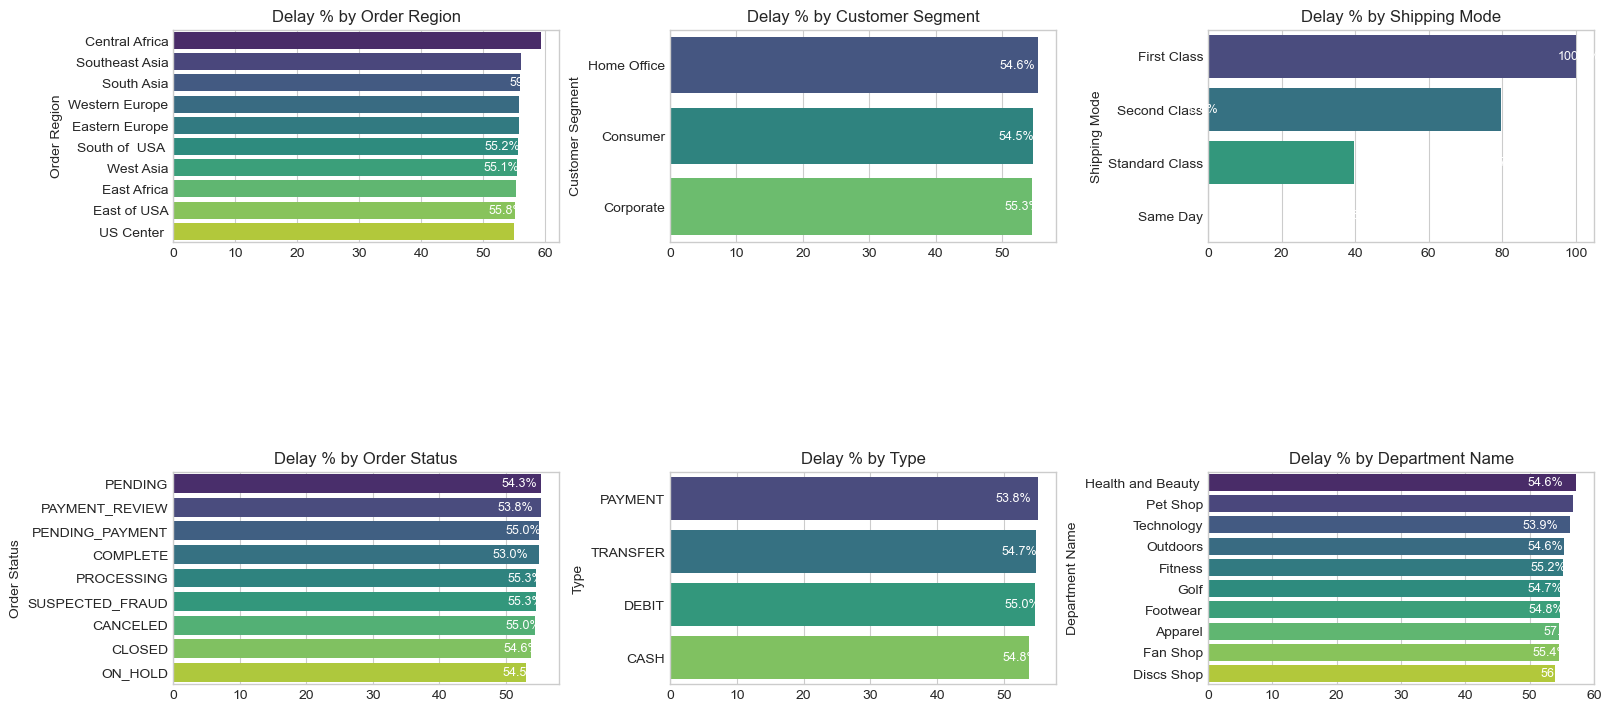

In [80]:
def compute_delay_pct_by_category(category):
    cat_df = df.groupby(category).agg(
        total_orders=('Delay', 'count'),
        late_orders=('Is_Delayed', 'sum')
    ).reset_index()

    cat_df['delay_pct'] = (cat_df['late_orders'] / cat_df['total_orders']) * 100
    cat_df = cat_df.sort_values('delay_pct', ascending=False).head(10)

    return cat_df


categories = [
    'Order Region',
    'Customer Segment',
    'Shipping Mode',
    'Order Status',
    'Type',
    'Department Name'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 7), constrained_layout=True)
axes = axes.flatten()

for ax, category in zip(axes, categories):
    cat_df = compute_delay_pct_by_category(category)   # 🔥 important fix

    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category,
        ax=ax,
        palette='viridis'
    )

    ax.set_title(f'Delay % by {category}')
    ax.set_xlabel('')
    ax.set_ylabel(category)

    for i, row in cat_df.iterrows():
        ax.text(row['delay_pct'] - 5, i,
                f"{row['delay_pct']:.1f}%",
                va='center', fontsize=9, color='white')

plt.show()

## Root Cause Analysis

In [83]:
# Top drivers of late delivery by region

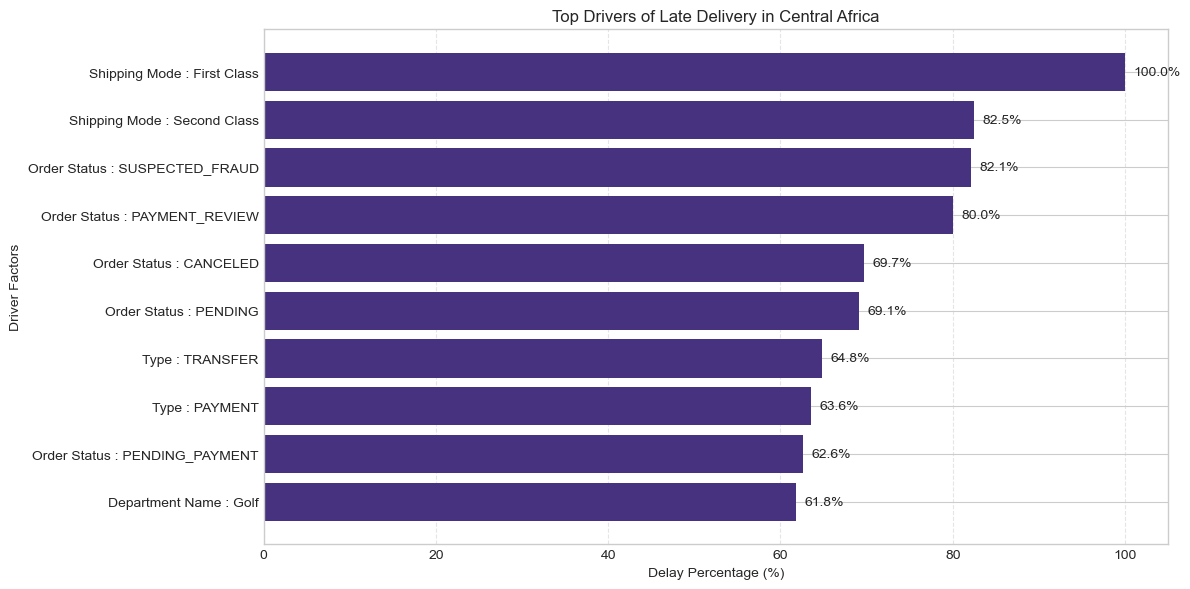

,Driver,Factor_Level,delay_pct,avg_delay,total_orders
0,Shipping Mode,Shipping Mode : First Class,100.000000,1.000000,300
2,Shipping Mode,Shipping Mode : Second Class,82.491582,2.127946,297
25,Order Status,Order Status : SUSPECTED_FRAUD,82.142857,1.035714,28
21,Order Status,Order Status : PAYMENT_REVIEW,80.000000,1.200000,20
17,Order Status,Order Status : CANCELED,69.696970,0.878788,33
22,Order Status,Order Status : PENDING,69.148936,0.574468,188
16,Type,Type : TRANSFER,64.830508,0.652542,472
15,Type,Type : PAYMENT,63.583815,0.763006,346
23,Order Status,Order Status : PENDING_PAYMENT,62.576687,0.736196,326
11,Department Name,Department Name : Golf,61.781609,0.686782,348


In [87]:
def top_drivers_for_region(region):

    # Select region data
    region_df = df[df['Order Region'] == region].copy()

    # Columns to analyze
    driver_columns = [
        'Shipping Mode',
        'Customer Segment',
        'Department Name',
        'Type',
        'Order Status'
    ]

    results = []

    # Loop through each driver column
    for col in driver_columns:

        summary = (
            region_df
            .groupby(col)
            .agg(
                total_orders=('Delay', 'count'),
                late_orders=('Is_Delayed', 'sum'),
                avg_delay=('Delay', 'mean')
            )
            .reset_index()
        )

        # Delay percentage
        summary['delay_pct'] = (
            summary['late_orders'] /
            summary['total_orders']
        ) * 100

        # Create labels
        summary['Driver'] = col
        summary['Factor_Level'] = (
            col + ' : ' + summary[col].astype(str)
        )

        # Keep required columns
        summary = summary[
            [
                'Driver',
                'Factor_Level',
                'delay_pct',
                'avg_delay',
                'total_orders'
            ]
        ]

        results.append(summary)

    # Merge all results
    final_data = pd.concat(results, ignore_index=True)

    # Get top 10 delay drivers
    top_drivers = (
        final_data
        .sort_values(by='delay_pct', ascending=False)
        .head(10)
    )

    # Visualization
    plt.figure(figsize=(12, 6))

    bars = plt.barh(
        top_drivers['Factor_Level'],
        top_drivers['delay_pct']
    )

    plt.xlabel('Delay Percentage (%)')
    plt.ylabel('Driver Factors')
    plt.title(f'Top Drivers of Late Delivery in {region}')

    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.gca().invert_yaxis()

    # Add labels on bars
    for bar in bars:

        value = bar.get_width()

        plt.text(
            value + 1,
            bar.get_y() + bar.get_height() / 2,
            f'{value:.1f}%',
            va='center'
        )

    plt.tight_layout()
    plt.show()

    return top_drivers


# Example
top_drivers_for_region('Central Africa')

# Time-Based Analysis

In [92]:
df['shipping date (DateOrders)'].min()

Timestamp('2015-01-03 00:00:00')

In [94]:
df['shipping date (DateOrders)'].max()

Timestamp('2018-02-06 22:14:00')

In [96]:
# Delay % by Month, Day of Week, Hour

delay_by_month = (
    df.groupby('order_month')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_month['delay_pct'] = delay_by_month['Is_Delayed'] * 100

delay_by_day = (
    df.groupby('order_day')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_day['delay_pct'] = delay_by_day['Is_Delayed'] * 100

delay_by_hour = (
    df.groupby('order_hour')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_hour['delay_pct'] = delay_by_hour['Is_Delayed'] * 100

In [100]:
delay_by_month

,order_month,Is_Delayed,delay_pct
0,1,0.541743,54.174314
1,2,0.545736,54.573611
2,3,0.549029,54.902946
3,4,0.544542,54.454163
4,5,0.550388,55.038808
5,6,0.545016,54.501618
6,7,0.541201,54.120085
7,8,0.552916,55.291604
8,9,0.552327,55.232746
9,10,0.541953,54.195291


In [104]:
delay_by_hour

,order_hour,Is_Delayed,delay_pct
0,0,0.539921,53.992095
1,1,0.553380,55.338008
2,2,0.553472,55.347241
3,3,0.539919,53.991935
4,4,0.538800,53.880036
5,5,0.552628,55.262811
6,6,0.523796,52.379642
7,7,0.551210,55.121043
8,8,0.530195,53.019502
9,9,0.544304,54.430380


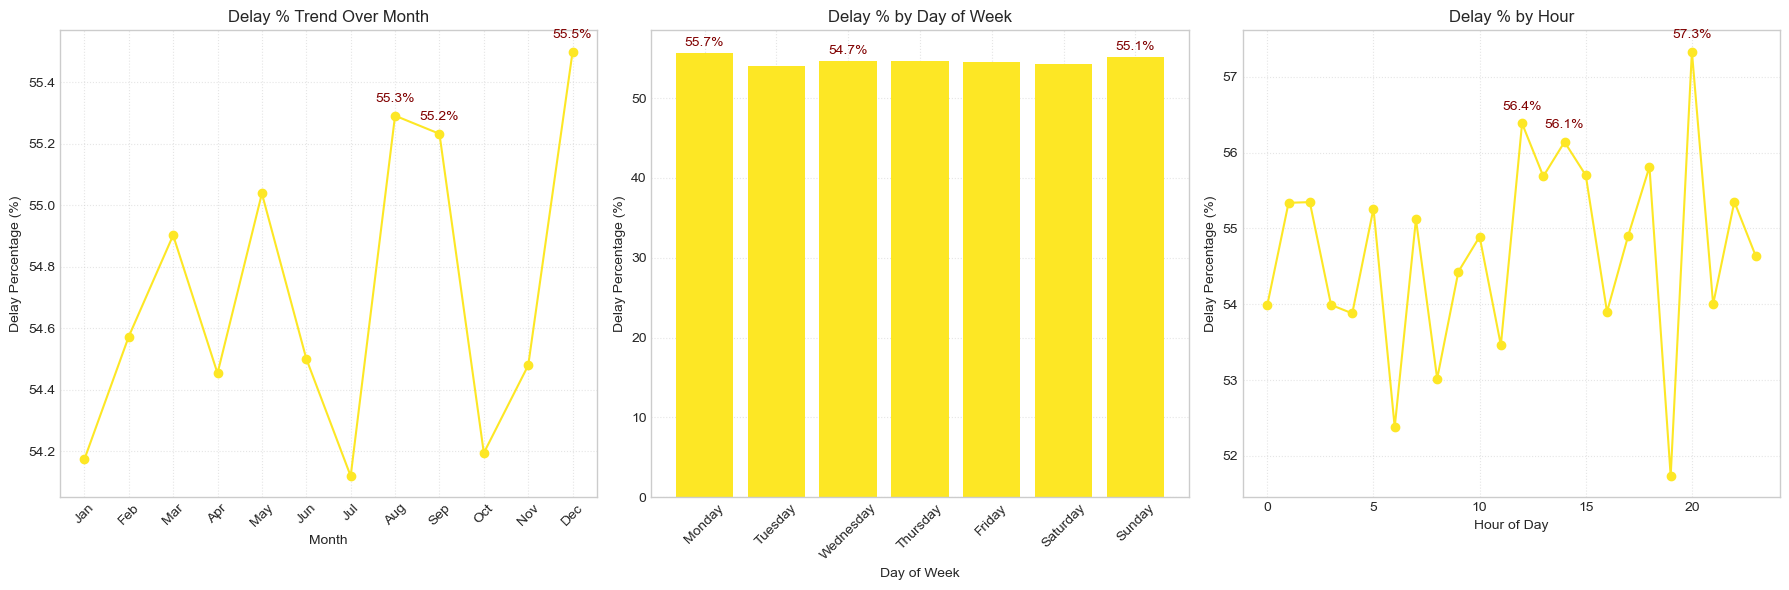

In [106]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Subplot 1: Delay % Trend Over Month
ax1.plot(delay_by_month['order_month'], delay_by_month['delay_pct'], marker='o', color=primary_color)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage (%)")
ax1.set_title("Delay % Trend Over Month")
ax1.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest
top3_month = delay_by_month.nlargest(3, 'delay_pct')
for _, row in top3_month.iterrows():
    ax1.annotate(f"{row['delay_pct']:.1f}%", (row['order_month'], row['delay_pct']),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color=danger_color)

# Subplot 2: Delay % by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
delay_by_day['order_day'] = pd.Categorical(delay_by_day['order_day'], categories=day_order, ordered=True)
delay_by_day = delay_by_day.sort_values('order_day')

ax2.bar(delay_by_day['order_day'], delay_by_day['delay_pct'], color=primary_color)
ax2.set_xticklabels(delay_by_day['order_day'], rotation=45)
ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Delay Percentage (%)")
ax2.set_title("Delay % by Day of Week")
ax2.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest bars
top3_day = delay_by_day.nlargest(3, 'delay_pct')
for _, row in top3_day.iterrows():
    height = row['delay_pct']
    ax2.text(row['order_day'], height + 0.5, f'{height:.1f}%', ha='center', va='bottom', fontsize=10, color=danger_color)

# Subplot 3: Delay % by Hour
ax3.plot(delay_by_hour['order_hour'], delay_by_hour['delay_pct'], marker='o', color=primary_color)
ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Delay Percentage (%)")
ax3.set_title("Delay % by Hour")
ax3.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest
top3_hour = delay_by_hour.nlargest(3, 'delay_pct')
for _, row in top3_hour.iterrows():
    ax3.annotate(f"{row['delay_pct']:.1f}%", (row['order_hour'], row['delay_pct']),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color=danger_color)

plt.tight_layout()
plt.show()

# Machine Learning Modeling

In [109]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
from imblearn.over_sampling import SMOTE

In [117]:
X = df[
    [
        'Type',
        'Days for shipment (scheduled)',
        'Category Name',
        'Customer Segment',
        'Department Name',
        'Order Region',
        'Shipping Mode',
        'order_month',
        'order_hour'
    ]
]

y = df['Late_delivery_risk']

In [119]:
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns:', cat_cols)

# Frequency encoding (low-dimensional and robust for high-cardinality)
for col in cat_cols:
    freq = X[col].value_counts(normalize=True)
    X[f'{col}_freq'] = X[col].map(freq)

# Keep numeric columns + new encoded features, drop original string categories
X_encoded = X.drop(columns=cat_cols)
print('Shape after freq+target encoding:', X_encoded.shape)

# use encoded features for modeling
X = X_encoded

# train/test split after encoding
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Categorical columns: ['Type', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region', 'Shipping Mode']
Shape after freq+target encoding: (180519, 9)


In [121]:
y.value_counts()

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

In [123]:
# Balancing the training data using SMOTE
print("Before balancing (train):", Counter(y_train))

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("After balancing (train):", Counter(y_train_bal))

Before balancing (train): Counter({1: 79181, 0: 65234})
After balancing (train): Counter({1: 79181, 0: 79181})


In [125]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n--- {model_name} ---")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 2))
    print("Precision:", round(precision_score(y_true, y_pred), 2))
    print("Recall:", round(recall_score(y_true, y_pred), 2))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

In [130]:
# Initialize the Random Forest classifier
rf_model_balanced = RandomForestClassifier(
    random_state=42
)

# Train the model using balanced training data
rf_model_balanced.fit(
    X_train_bal,
    y_train_bal
)

# Predict on test data
y_pred_rf_balanced = rf_model_balanced.predict(
    X_test
)

# Evaluate model
evaluate_model(
    y_test,
    y_pred_rf_balanced,
    "Random Forest Classifier"
)


--- Random Forest Classifier ---
Accuracy: 0.73
Precision: 0.77
Recall: 0.74

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.73      0.71     16308
           1       0.77      0.74      0.75     19796

    accuracy                           0.73     36104
   macro avg       0.73      0.73      0.73     36104
weighted avg       0.74      0.73      0.73     36104

